# Four Data Visualization Problems

By Yusuf Oğuz

## Problem 1: Favorite Video Game Characters

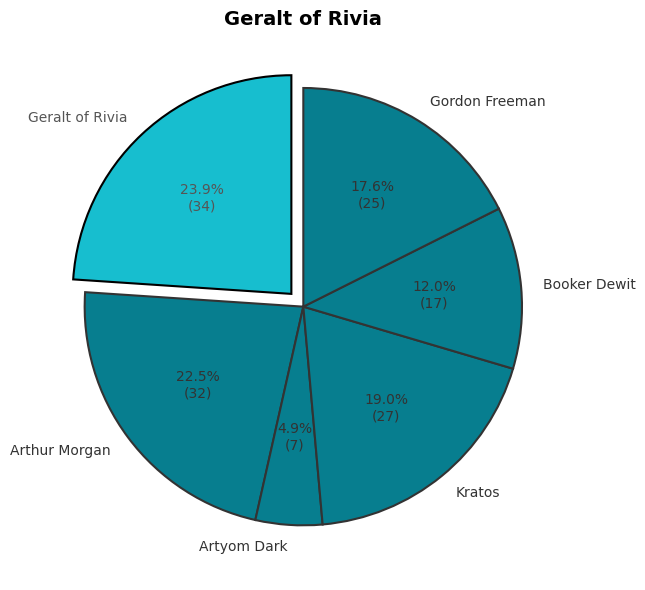

In [1]:
import matplotlib.pyplot as plt

def problem1(data):
    #produces a pie chart  showing favorit video game characters
    # the most popular characters slice is highlighted and pulled out
    labels = list(data.keys())
    sizes  = list(data.values())

    #find the largest slice it will also be the title
    max_idx = sizes.index(max(sizes))
    explode = [0.08 if i == max_idx else 0 for i in range(len(sizes))]

    # highlighted slice gets the lighter color others get dark
    colors = ['#17BECF' if i == max_idx else '#077E8F' for i in range(len(sizes))]

    # autopct shows both percentage and raw count
    # used a closure so we can acces the original values inside the formatter
    def make_autopct(values):
        def inner(pct):
            # convert percentage back to the actual integer count
            val = int(round(pct*sum(values)/100.0))
            return f'{pct:.1f}%\n({val})'
        return inner

    fig, ax = plt.subplots(figsize=(8,6))

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        explode=explode,
        autopct=make_autopct(sizes),
        startangle=90,
        wedgeprops=dict(linewidth =1.5)
    )

    # set text and edge colors separatly for each wedge
    # highlighted wedge: black border #555555 text
    # others: #333333 border and text (as specified in the problem)
    for i in range(len(wedges)):
        if i == max_idx:
            wedges[i].set_edgecolor('black')
            texts[i].set_color('#555555')
            autotexts[i].set_color('#555555')
        else:
            wedges[i].set_edgecolor('#333333')
            texts[i].set_color('#333333')
            autotexts[i].set_color('#333333')

    # title is the name of the highligted character
    ax.set_title(labels[max_idx], fontsize=14,fontweight='bold')

    plt.tight_layout()
    return fig


data = {
    "Geralt of Rivia": 34, "Arthur Morgan": 32,
    "Artyom Dark": 7,      "Kratos": 27,
    "Booker Dewit": 17,    "Gordon Freeman": 25
}

problem1(data);


## Problem 2: Global Corporate AI Investment

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def problem2(filename):
    # plots  annual global corporate ai investment as a line chart
    df = pd.read_csv(filename)

    # only keeping worldlevel rows (no country breakdown in this datset anyway)
    df = df[df['Entity'] == 'World'].sort_values('Year')

    years  = df['Year'].values
    invest = df['total_corporate_investment_inflation_adjusted'].values

    # convert raw dollar values to  billions for readabilty on the axis
    invest_b = invest/1e9

    fig, ax = plt.subplots(figsize=(9,5))

    ax.plot(years, invest_b, color='steelblue', linewidth=2,marker='o', markersize=4)

# yticks every 20 billion formatted as "$X billion"
    # +20 makes sure the top tick covers the max vale
    max_val = invest_b.max()
    yticks = range(0, int(max_val)+20, 20)
    ax.set_yticks(list(yticks))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${int(x)} billion'))

    # remove left right and top spines as required
    for spine in ['left', 'right', 'top',]:
        ax.spines[spine].set_visible(False)

    # grid only for yaxis helps read values without cluutering
    ax.yaxis.grid(True, linestyle='--',alpha=0.7)
    ax.set_axisbelow(True)  # gridlines behind the plot

    ax.set_xticks(years)
    ax.set_xlabel('Year')

    plt.tight_layout()
    return fig


problem2('data/corporate-investment-in-artificial-intelligence-total.csv');

## Problem 3: AI Compute Scaling (2012-2024)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch

def problem3(filename):
    # produces a 4 panel figure analysing AI model scaling from 2012 to  2024
    df = pd.read_csv(filename)

    fig, axes = plt.subplots(2, 2, figsize=(14,10))
    fig.suptitle('AI Compute Scaling Analysis (2012-2024)', fontsize=13,fontweight='bold')

    # (a) Model Size vs Compute  upperleft
    ax = axes[0, 0]

    # assign a unique color per organization  using tab10 colormap
    orgs = df['Organization'].unique()
    color_map = {org: cm.tab10(i/len(orgs)) for i, org in enumerate(orgs)}

    # different markers for three time periods to show generatonal shift
    def get_marker(year):
        if year <= 2017:
            return 'o'   # early models
        elif year <= 2021:
            return 's'   # midera models
        else:
            return '^'   # recent large models

    for _, row in df.iterrows():
        ax.scatter(
            row['Training_Computeflop'],
            row['Parameters_Billions'],
            color=color_map[row['Organization']],
            marker=get_marker(row['Year']),
            s=60,zorder=3
        )
        # annotate each point with the model name in smll font
        ax.annotate(row['Model'], (row['Training_Computeflop'], row['Parameters_Billions']),
                    fontsize=6,xytext=(4, 2), textcoords='offset points')

    # log scale on both axes becuse model sizes span several orders of magnitude
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Training Compute (FLOPs)', fontsize=8)
    ax.set_ylabel('Parameters (Billions)', fontsize=8)
    ax.set_title('(a) Model Size vs Compute', fontsize=9)

    # build legend using empty scatter calls (no actual data ploted)
    for org, color in color_map.items():
        ax.scatter([], [], color=color, label=org, s=40)
    ax.legend(fontsize=5, loc='upper left',framealpha=0.6)

    # (b) Temporal Compute Scaling  upperright
    ax = axes[0, 1]

    # group by year to get median min and max compute per year
    grouped = df.groupby('Year')['Training_Computeflop']
    years   = sorted(df['Year'].unique())
    medians = grouped.median().reindex(years).values
    mins    = grouped.min().reindex(years).values
    maxs    = grouped.max().reindex(years).values

    ax.plot(years, medians, color='steelblue', linewidth=2,marker='o', markersize=4)
    # shaded region shows variance (min to max) across models in each  year
    ax.fill_between(years, mins, maxs, alpha =0.2,color='steelblue', label='min-max range')

    ax.set_yscale('log')
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel('Training Compute (FLOPs)', fontsize=8)
    ax.set_title('(b) Temporal Compute Scaling', fontsize=9)
    ax.legend(fontsize=7)

    # (c) Model Efficiency Analysis  lowerleft
    ax = axes[1, 0]

    # compute efficiency metric: how much compute was spent per toekn of training data
    # lower value = more efficent model
    df['Compute_per_Token'] = df['Training_Computeflop'] / df['Training_Data_Tokens_Billions']

    # nsmallest gives us the 10 lowest (most efficient) then sort for ascending bar chart
    top10 = df.nsmallest(10, 'Compute_per_Token').sort_values('Compute_per_Token')

    # color bars by era: blue = before 2020  orange = 2020 and after
    bar_colors = ['#4C72B0' if y < 2020 else '#F4A736' for y in top10['Year']]

    ax.bar(top10['Model'], top10['Compute_per_Token'], color=bar_colors)
    ax.set_xlabel('Model', fontsize=8)
    ax.set_ylabel('Compute per Token', fontsize=8)
    ax.set_title('(c) Model Efficiency (lower = more efficient)', fontsize=9)
    ax.tick_params(axis='x', rotation=45,labelsize=7)

    # simple legend for the colors
    
    legend_els = [Patch(color='#4C72B0', label='Before 2020'),
                  Patch(color='#F4A736', label='2020 and after')]
    ax.legend(handles=legend_els, fontsize=7)

    # (d) Correlation Heatmap  lowerright
    ax = axes[1, 1]

    cols = ['Parameters_Billions', 'Training_Computeflop',
            'Training_Data_Tokens_Billions', 'Training_Time_Days', 'Context_Length']
    corr = df[cols].corr()

    # short labels so they fit inside the hetmap cells
    short = ['Params', 'Compute', 'Tokens', 'Time', 'Context']
    im = ax.imshow(corr.values, cmap='viridis',vmin=-1, vmax=1)

    ax.set_xticks(range(len(short)))
    ax.set_yticks(range(len(short)))
    ax.set_xticklabels(short, fontsize=7,rotation=45, ha='right')
    ax.set_yticklabels(short, fontsize=7)

    # annotate each cell with the correlation coeficient rounded to 2 decimals
    for i in range(len(short)):
        for j in range(len(short)):
            ax.text(j, i, f'{corr.values[i, j]:.2f}',
                    ha='center',va='center', fontsize=7)

    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title('(d) Correlation Heatmap', fontsize=9)

    plt.tight_layout()
    fig.savefig('ai_scaling_analysis.png', dpi=150,bbox_inches='tight')
    return fig


problem3('data/ai_compute_scaling.csv');

## Problem 4: Player Attributes

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch

def problem4(filename):
    # threepanel visualization of player attributes
    # panels: donut chart swarm scatter parallel coordinates
    df = pd.read_csv(filename)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Player Attributes Analysis', fontsize=13, fontweight='bold')

    #Panel A: Donut Chart
    ax = axes[0]

    attrs = ['Pace', 'Shooting', 'Passing', 'Dribbling',
             'Defending', 'Physical', 'Overall', 'Potential']

    # compute the mean of each  attribute across all players
    means = df[attrs].mean()

    pastel_colors = [
        '#AEC6CF', '#FFD1DC', '#B5EAD7', '#FFDAC1',
        '#C7CEEA', '#E2F0CB', '#FFB7B2', '#FF9AA2'
    ]

    # width < 1 creates the donut hole 0.5 means half the radius is cut out
    wedges, texts, autotexts = ax.pie(
        means,
        labels=attrs,
        colors=pastel_colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.5)
    )

    for at in autotexts:
        at.set_fontsize(7)
    for t in texts:
        t.set_fontsize(8)

    # center text sits in the donut  hole
    ax.text(0, 0, 'Avg\nAttrs', ha='center', va='center', fontsize=9, fontweight='bold')
    ax.set_title('Panel A — Avg Attribute Strengths', fontsize=9)

    # Panel B:Swarmstyle Scatter
    ax = axes[1]

    # three attributes become the xaxis categories
    categories = ['Pace', 'Shooting', 'Passing']
    cat_pos    = {c: i for i, c in enumerate(categories)}

    # one color per  country using tab10
    countries = df['Country'].unique()
    cmap = cm.tab10
    country_color = {c: cmap(i / len(countries)) for i, c in enumerate(countries)}

    np.random.seed(42)  # fixed seed so jitter is reproducable
    for _, row in df.iterrows():
        for cat in categories:
            x = cat_pos[cat] + np.random.uniform(-0.15, 0.15)  # manual jitter on xaxis
            y = row[cat]
            size = (row['Overall'] - 85) * 15   # marker size scald by Overall score
            ax.scatter(x, y, color=country_color[row['Country']],
                       s=size, alpha=0.6, edgecolors='none')

    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories)
    ax.set_ylabel('Score')
    ax.set_title('Panel B — Pace / Shooting / Passing by Country', fontsize=9)

    # legend for countries
    legend_els = [Patch(color=country_color[c], label=c) for c in countries]
    ax.legend(handles=legend_els, fontsize=7, loc='lower right')

    #Panel C: Parallel Coordinates
    ax = axes[2]

    pc_attrs = ['Pace', 'Shooting', 'Passing', 'Dribbling', 'Defending']

    # normalize each feature to [0,1] so all axes are comparable
    normed = df[pc_attrs].copy()
    for col in pc_attrs:
        normed[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

    # divide players into 5 quintile groups basd on Overall rating
    # duplicates='drop' handles tied bin edges in small datsets
    df['quintile'] = pd.qcut(df['Overall'], 5, labels=False, duplicates='drop')
    q_colors = cm.plasma(np.linspace(0.1, 0.9, 5))

    # draw one line per player colored by their quintile group
    x_vals = range(len(pc_attrs))
    for _, row in normed.iterrows():
        q = df.loc[row.name, 'quintile']
        ax.plot(x_vals, row[pc_attrs].values,
                color=q_colors[q], alpha=0.7, linewidth=1.2)

    # thin vertical axes mark each  attribute
    for xi in x_vals:
        ax.axvline(xi, color='black', linewidth=0.8)

    ax.set_xticks(list(x_vals))
    ax.set_xticklabels(pc_attrs, fontsize=8)
    ax.set_yticks([])   # no yaxis ticks values are normalized anyway
    ax.set_facecolor('white')
    # remove all spines for a  clean look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.set_title('Panel C — Parallel Coordinates', fontsize=9)

    # legend explins what each color represents
    q_labels = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)']
    legend_els = [Patch(color=q_colors[i], label=q_labels[i]) for i in range(5)]
    ax.legend(handles=legend_els, fontsize=7, loc='lower right', title='Overall Quintile', title_fontsize=7)

    plt.tight_layout()
    return fig


problem4('data/player_attributes.csv');